# HadISD with PyEarthTools & XGBoost
HadISD is a global sub-daily dataset based on the ISD dataset from NOAA's NCEI. As well as station selection criteria, a suite of quality control tests has been run on the major climatological variables.

For this demonstration we are using version 3.4.0.2023f of the dataset, which can be downloaded here: https://www.metoffice.gov.uk/hadobs/hadisd/v340_2023f/download.html

Before the dataset can be used, it must be converted to Zarr. Please refer to the HadISD_to_Zarr jupyter notebook for information on how to do this.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

import pyearthtools.pipeline as petpipe
import pyearthtools.data as petdata
from pyearthtools.tutorial.HadisdDataClass import HadISDIndex

The following cell is used to run a pipeline configuration notebook that allows custom pipeline steps to be defined and included in the pipeline.

In [2]:
# ruff: noqa: F821
%run Pipeline_Config.ipynb

## Creating an ordered list of all available HadISD station IDs
The  HadISDIndex class contains a method called "get_alL station_ids" that can be used to create a list of all available station IDS. This list can be used to select, for example, the first_ten stations from all stations. It can then be passedto select data from within the pipeline. It's also possible to pass a single station ID as a string to retrieve data for a single station.

In [3]:
hadisd = HadISDIndex()
all_stations = hadisd.get_all_station_ids()
all_stations_ordered = sorted(all_stations)
print(f"Total number of stations: {len(all_stations_ordered)}")

Total number of stations: 770


In [4]:
# Select first n stations
first_ten_stations = all_stations_ordered[:10]
print("List of first ten stations:", first_ten_stations)

List of first ten stations: ['501360-99999', '502460-99999', '503530-99999', '504340-99999', '504420-99999', '504680-99999', '505270-99999', '505480-99999', '505570-99999', '505640-99999']


## Pre-Training Data Pipeline
- Hadisd accepts "all" as an argument to get all stations.
- A single station can also be specified, e.g., "010010-99999".
- A list of station IDs can also be passed, e.g., ["010010-99999", "010014-99999"]

To demonstarte the piepline, we will pass the list we created above called "first_ten_stations"

Many of the variables and pipeline steps below have been taken from the `Pipeline_Config.ipynb` notebook using the %run command.


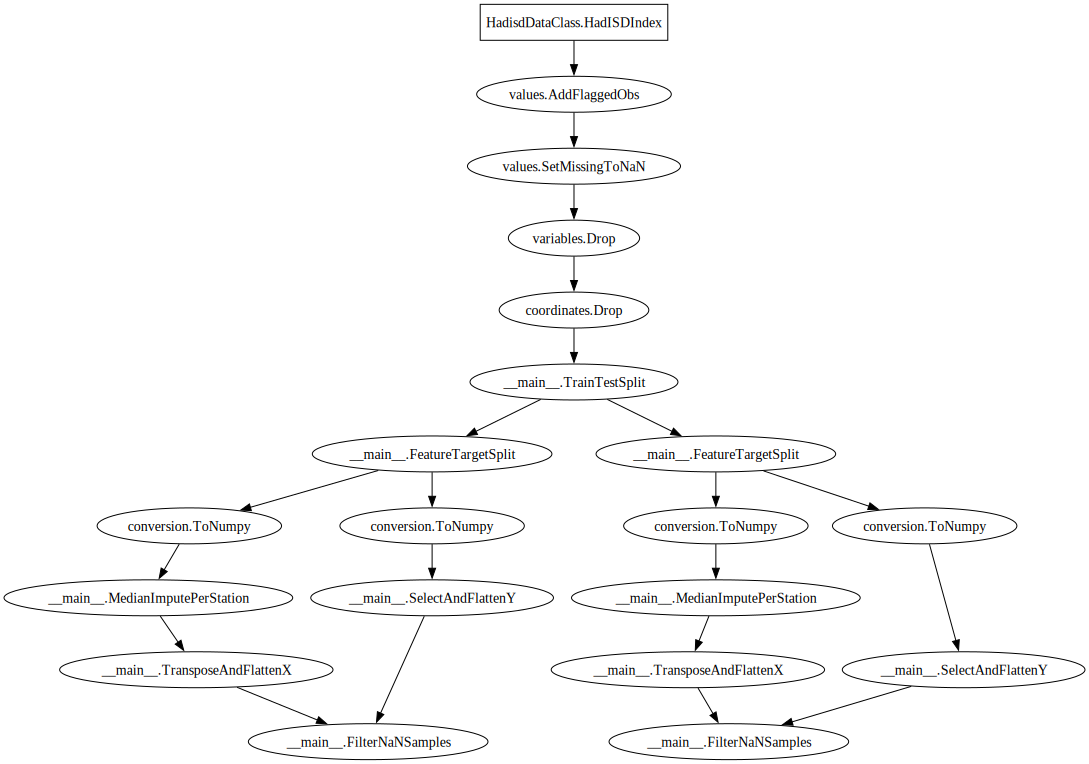

In [5]:
data_prep_pipe = petpipe.Pipeline(
    petdata.archive.hadisd(station = first_ten_stations), # Use all stations
    petdata.transforms.values.AddFlaggedObs(flagged_labels),
    petdata.transforms.values.SetMissingToNaN(varname_val_map),
    petdata.transforms.variables.Drop("flagged_obs"),
    petdata.transforms.coordinates.Drop(['latitude', 'longitude', 'elevation']),
    TrainTestSplit(test_size=0.2, random_state=42, dim='time'),  # returns (ds_train, ds_test)
    (
        # branch 1: train
        (
            FeatureTargetSplit(target_vars="quality_control_flags"),
            (
                # branch X_train
                (
                    petpipe.operations.xarray.conversion.ToNumpy(),
                    MedianImputePerStation(),
                    TransposeAndFlattenX(),
                ),
                # branch y_train
                (
                     petpipe.operations.xarray.conversion.ToNumpy(),
                    SelectAndFlattenY(test_number=33),
                ),
                'map'
            ),
            FilterNaNSamples(),  # filters (X_train, y_train)
        ),
        # branch 2: test
        (
            FeatureTargetSplit(target_vars="quality_control_flags"),
            (
                # branch X_test
                (
                    petpipe.operations.xarray.conversion.ToNumpy(),
                    MedianImputePerStation(),
                    TransposeAndFlattenX(),
                ),
                # branch y_test
                (
                    petpipe.operations.xarray.conversion.ToNumpy(),
                    SelectAndFlattenY(test_number=33),
                ),
                'map'
            ),
            FilterNaNSamples(),  # filters (X_test, y_test)
        ),
        'map'
    )
)
data_prep_pipe

In [6]:
# Select data based on date
(X_train, y_train),(X_test, y_test) = data_prep_pipe["1969-01-01T00"] # Curretnly we have to select a date outside of the date range to select the entire dataset (fix coming soon)

/Users/joelmiller/Projects/Python/PyEarthTools_Fork/PyEarthTools/packages/data/src/pyearthtools/data/indexes/_indexes.py:487: IndexWarning: Could not find time in dataset to select on. Petdt('1969-01-01T00')
  warnings.warn(


In [7]:
# Print the shapes of the resulting arrays
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (920121, 22)
y_train shape: (920121,)
X_test shape: (232093, 22)
y_test shape: (232093,)


## Train Model using XGBoost with output from the pipeline

In [8]:
# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (len(y_train) - np.sum(y_train)) / np.sum(y_train)
#scale_pos_weight = num_zeros / num_ones 

# Create and fit model
classifier = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)
classifier.fit(X_train, y_train)

# Predict on test set
y_pred = classifier.predict(X_test)

/Users/joelmiller/miniconda3/envs/pyearthtools/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [17:41:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Confusion Matrix and Classification Report

In [9]:
# compare predictions with true labels
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred)) 

              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98    223592
         1.0       0.53      0.76      0.63      8501

    accuracy                           0.97    232093
   macro avg       0.76      0.87      0.80    232093
weighted avg       0.97      0.97      0.97    232093

[[217897   5695]
 [  2013   6488]]


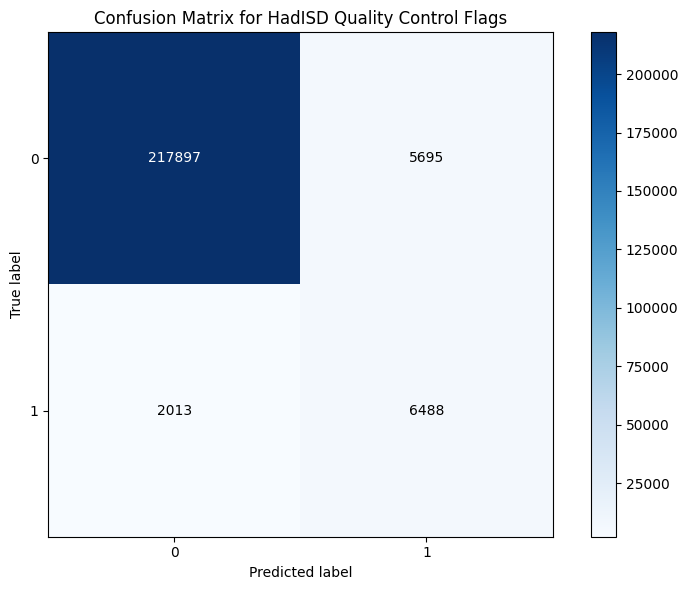

In [10]:
# Plot confusion matrix using only matplotlib
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    # Annotate cells with counts
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, classes=['0', '1'], title='Confusion Matrix for HadISD Quality Control Flags')